<a href="https://colab.research.google.com/github/kaylatucker/CS690_Capstone/blob/main/03_notebooks/08_customer_eda_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Customer EDA

### Load Data

In [2]:
!git clone https://github.com/kaylatucker/CS690_Capstone.git

Cloning into 'CS690_Capstone'...
remote: Enumerating objects: 213, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 213 (delta 91), reused 23 (delta 11), pack-reused 40 (from 4)
Receiving objects: 100% (213/213), 85.08 MiB | 16.82 MiB/s, done.
Resolving deltas: 100% (93/93), done.
Updating files: 100% (46/46), done.


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO_DIR = Path("/content/CS690_Capstone")
PROCESSED_DIR = REPO_DIR / "02_data" / "processed"

customer_experience = pd.read_csv(
    PROCESSED_DIR / "customer_experience.csv",
    dtype={
        "customer_zip_code_prefix": str,
        "seller_zip_code_prefix": str
    }
)

print("Rows:", len(customer_experience))
print("Unique orders:", customer_experience["order_id"].nunique())
print("Duplicate orders:", customer_experience["order_id"].duplicated().sum())

Rows: 99441
Unique orders: 99441
Duplicate orders: 0


### Review-score summary

In [4]:
print("Review score summary:")
display(
    customer_experience["review_score"]
    .describe()
    .round(2)
)

print("\nOrders with review scores:",
      customer_experience["review_score"].notna().sum())

print("Orders missing review scores:",
      customer_experience["review_score"].isna().sum())

Review score summary:


,review_score
count,98673.00
mean,4.09
std,1.35
min,1.00
25%,4.00
50%,5.00
75%,5.00
max,5.00



Orders with review scores: 98673
Orders missing review scores: 768


### Delivery status vs. review score

In [5]:
review_by_delivery = (
    customer_experience
    .dropna(subset=["review_score", "late_delivery_flag"])
    .groupby("late_delivery_flag")["review_score"]
    .agg(["count", "mean", "median"])
    .round(2)
)

review_by_delivery.index = ["On Time", "Late"]

display(review_by_delivery)

,count,mean,median
On Time,88168,4.29,5.0
Late,7662,2.57,2.0


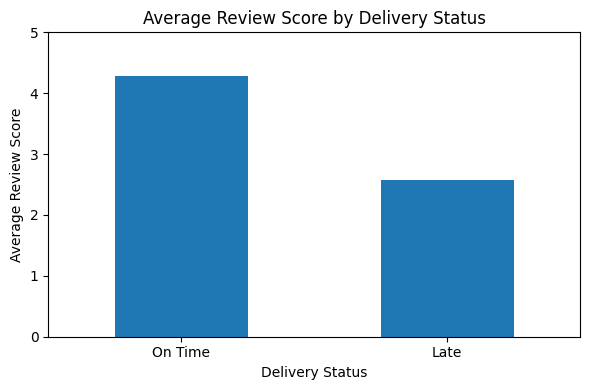

In [6]:
plt.figure(figsize=(6, 4))

review_by_delivery["mean"].plot(kind="bar")

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Delivery delay vs. review score

In [7]:
delay_by_review = (
    customer_experience
    .dropna(subset=["review_score", "delivery_delay_days"])
    .assign(
        review_score_display=lambda x: x["review_score"].round()
    )
    .groupby("review_score_display")["delivery_delay_days"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(delay_by_review)

,count,mean,median
review_score_display,,,
1.0,9316,-3.34,-6.37
2.0,2954,-7.92,-9.31
3.0,7917,-10.08,-10.36
4.0,18945,-11.69,-11.50
5.0,56698,-12.68,-12.32


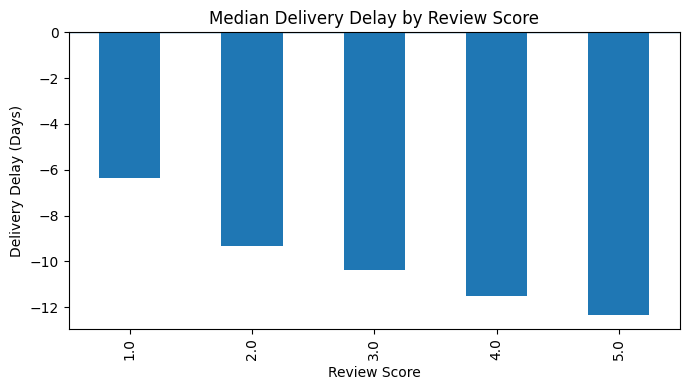

In [10]:
plt.figure(figsize=(7, 4))

delay_by_review["median"].plot(kind="bar")

plt.title("Median Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Delay (Days)")
plt.xticks(rotation=0)

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

- Customer review scores are generally high, with a mean of 4.09 and a median of 5.
- On-time orders have a substantially higher average review score (4.29) than late orders (2.57).
- Median review score is 5 for on-time orders and 2 for late orders.
- Higher review scores are also associated with earlier delivery relative to the estimated date.
- Five-star orders were delivered a median of about 12.3 days before the estimated date, compared with about 6.4 days early for one-star orders.
- These patterns suggest that delivery performance is strongly related to customer experience, but the EDA does not establish causation.

### Order value vs. review score

In [11]:
order_value_by_review = (
    customer_experience
    .dropna(subset=["review_score", "order_value"])
    .assign(
        review_score_display=lambda x: x["review_score"].round()
    )
    .groupby("review_score_display")["order_value"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(order_value_by_review)

,count,mean,median
review_score_display,,,
1.0,10778,166.97,99.00
2.0,3104,145.26,89.90
3.0,8084,127.63,82.97
4.0,19066,132.37,84.00
5.0,56885,134.67,84.99


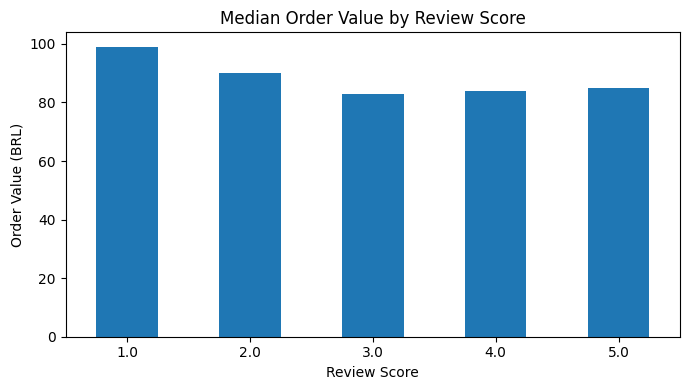

In [12]:
plt.figure(figsize=(7, 4))

order_value_by_review["median"].plot(kind="bar")

plt.title("Median Order Value by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Order Value (BRL)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Freight percentage vs. review score

In [13]:
freight_by_review = (
    customer_experience
    .dropna(subset=["review_score", "freight_percentage"])
    .assign(
        review_score_display=lambda x: x["review_score"].round()
    )
    .groupby("review_score_display")["freight_percentage"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(freight_by_review)

,count,mean,median
review_score_display,,,
1.0,10778,31.67,22.76
2.0,3104,32.35,23.53
3.0,8084,32.56,23.74
4.0,19066,31.34,22.53
5.0,56885,30.20,22.16


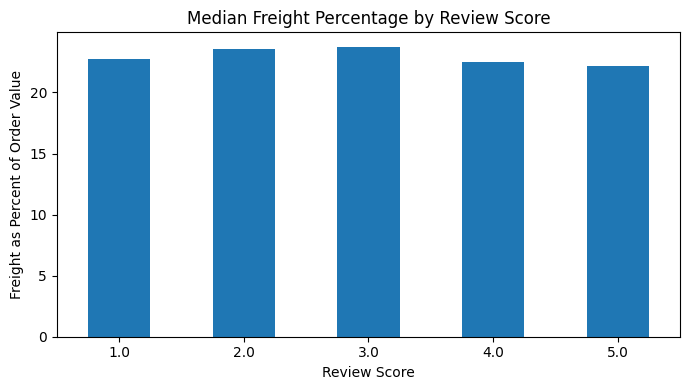

In [14]:
plt.figure(figsize=(7, 4))

freight_by_review["median"].plot(kind="bar")

plt.title("Median Freight Percentage by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Freight as Percent of Order Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Order value and freight findings

- Lower review scores are associated with somewhat higher order values.
- One-star orders have a median order value of about 99 BRL, compared with approximately 83–85 BRL for three- to five-star orders.
- Freight percentage varies much less across review-score groups.
- Median freight percentage remains around 22–24% across all review levels.
- These findings suggest that order value may deserve further investigation, while freight percentage shows a weaker descriptive relationship with review score than delivery performance.
- These are exploratory associations and do not establish causation.

### Product Category

In [15]:
category_review = (
    customer_experience
    .dropna(subset=["primary_category", "review_score"])
    .groupby("primary_category")
    .agg(
        order_count=("order_id", "count"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

category_review = category_review[
    category_review["order_count"] >= 500
].sort_values(
    "average_review_score",
    ascending=False
)

display(category_review)

,primary_category,order_count,average_review_score
8,books_general_interest,507,4.461538
53,luggage_accessories,1022,4.340509
68,stationery,2272,4.253301
61,pet_shop,1692,4.247045
60,perfumery,3133,4.206671
71,toys,3808,4.198398
28,fashion_bags_accessories,1850,4.187838
56,musical_instruments,617,4.186386
20,cool_stuff,3556,4.186164
65,small_appliances,619,4.185784


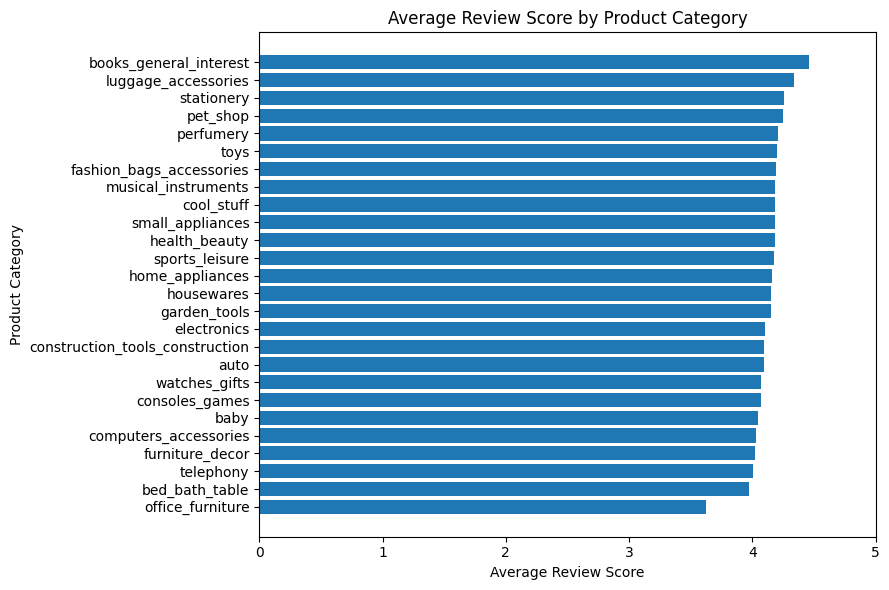

In [16]:
plt.figure(figsize=(9, 6))

plot_data = category_review.sort_values(
    "average_review_score"
)

plt.barh(
    plot_data["primary_category"],
    plot_data["average_review_score"]
)

plt.title("Average Review Score by Product Category")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

- Average review scores vary somewhat across major product categories, although most categories fall near 4.0–4.3.
- `books_general_interest` had the highest average review score among categories with at least 500 orders at about 4.46.
- `office_furniture` had the lowest average at about 3.63, making it a notable category for later investigation.
- Category may contribute to differences in customer experience, but the variation is smaller than the delivery-status differences observed earlier.

### Seller Characteristics

In [17]:
seller_scale_by_review = (
    customer_experience
    .dropna(subset=["review_score", "seller_order_count"])
    .assign(
        review_score_display=lambda x: x["review_score"].round()
    )
    .groupby("review_score_display")["seller_order_count"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(seller_scale_by_review)

,count,mean,median
review_score_display,,,
1.0,10327,378.12,151.0
2.0,2953,417.14,174.0
3.0,7919,420.82,167.0
4.0,18935,386.02,159.0
5.0,56519,363.12,149.0


In [18]:
seller_variety_by_review = (
    customer_experience
    .dropna(subset=["review_score", "seller_product_count"])
    .assign(
        review_score_display=lambda x: x["review_score"].round()
    )
    .groupby("review_score_display")["seller_product_count"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(seller_variety_by_review)

,count,mean,median
review_score_display,,,
1.0,10327,72.78,37.0
2.0,2953,80.34,40.0
3.0,7919,79.40,39.0
4.0,18935,72.37,37.0
5.0,56519,68.67,36.0


- Seller order volume does not show a clear monotonic relationship with customer review score.
- Median seller order counts are relatively similar across review-score groups.
- Seller product variety also differs only slightly across review-score groups.
- These seller-scale measures may still be useful as control variables in later analysis, but they do not show a strong descriptive relationship with review score in the initial EDA.

### Geography

In [19]:
customer_state_review = (
    customer_experience
    .dropna(subset=["customer_state", "review_score"])
    .groupby("customer_state")
    .agg(
        order_count=("order_id", "count"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

customer_state_review = customer_state_review[
    customer_state_review["order_count"] >= 500
].sort_values(
    "average_review_score",
    ascending=False
)

display(customer_state_review)

,customer_state,order_count,average_review_score
17,PR,5019,4.181112
25,SP,41472,4.174126
10,MG,11554,4.135754
22,RS,5443,4.133658
11,MS,713,4.109397
12,MT,900,4.101667
23,SC,3609,4.073705
6,DF,2128,4.066964
8,GO,2007,4.043348
7,ES,2006,4.038385


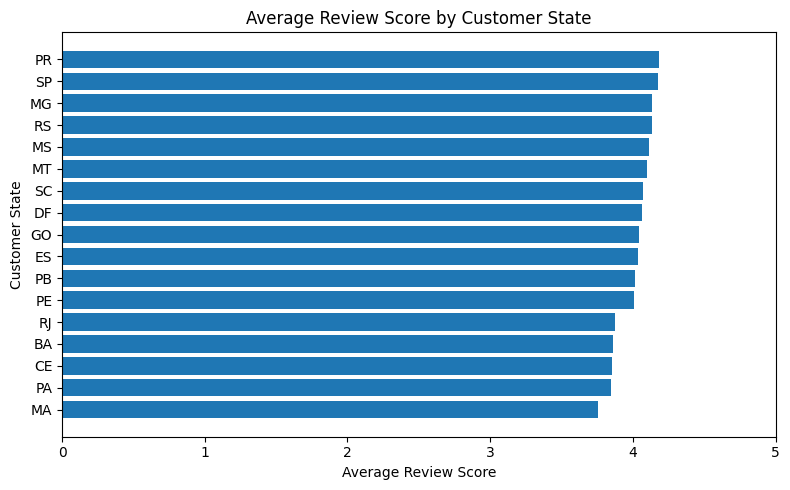

In [20]:
plt.figure(figsize=(8, 5))

plot_data = customer_state_review.sort_values(
    "average_review_score"
)

plt.barh(
    plot_data["customer_state"],
    plot_data["average_review_score"]
)

plt.title("Average Review Score by Customer State")
plt.xlabel("Average Review Score")
plt.ylabel("Customer State")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [21]:
geo_orders = customer_experience.dropna(
    subset=["customer_state", "seller_state", "review_score"]
).copy()

geo_orders["same_state"] = (
    geo_orders["customer_state"] == geo_orders["seller_state"]
)

same_state_review = (
    geo_orders
    .groupby("same_state")["review_score"]
    .agg(["count", "mean", "median"])
    .round(2)
)

same_state_review.index = [
    "Different State",
    "Same State"
]

display(same_state_review)

,count,mean,median
Different State,61884,4.06,5.0
Same State,34769,4.23,5.0


# Notes

- Customer-experience EDA was conducted using `customer_experience.csv`, which contains one row per order.
- The dataset contains 99,441 unique orders with no duplicate order IDs.
- `review_score` remains the primary customer-experience outcome; 98,673 orders have review information and 768 are missing a review score.
- Customer reviews are generally high, with a mean review score of 4.09 and a median of 5.
- Delivery performance shows the clearest relationship with customer experience found during initial EDA.
- On-time orders have an average review score of 4.29 compared with 2.57 for late orders; median review scores are 5 and 2, respectively.
- Higher review scores are also associated with earlier delivery relative to the estimated date. Five-star orders were delivered a median of about 12.3 days early compared with about 6.4 days early for one-star orders.
- Lower-rated orders tend to have somewhat higher order values. One-star orders have a median value of about 99 BRL, compared with approximately 83–85 BRL for three- to five-star orders.
- Freight percentage shows relatively little variation across review-score groups, with median values remaining around 22–24% of order value.
- Average review scores vary somewhat across major product categories. Among categories with at least 500 orders, `books_general_interest` had the highest average review score at about 4.46 and `office_furniture` had the lowest at about 3.63.
- Seller order volume and seller product variety do not show a strong or consistent descriptive relationship with customer review score.
- Customer review scores vary somewhat by state. Among states with at least 500 reviewed orders, average review scores range from about 3.76 to 4.18.
- Orders where the customer and seller are in the same state have a slightly higher average review score (4.23) than orders involving different states (4.06), although both groups have a median review score of 5.
- Delivery performance currently appears more strongly related to customer experience than order value, freight percentage, seller scale, or geography.
- All findings are exploratory associations and should not be interpreted as causal relationships.
- The next analytical stage should determine which of these relationships remain meaningful when other variables are considered simultaneously.